In [1]:
import pandas as pd
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load spaCy model
nlp = spacy.load("en_core_web_sm")

In [6]:
# Step 1: Load the dataset
df = pd.read_csv("/content/Reviews.csv", on_bad_lines='skip', engine='python', encoding='utf-8')
df = df[['Score', 'Summary', 'Text']].dropna().reset_index(drop=True)


In [7]:
# Step 2: Preprocess the text using spaCy
def preprocess_text(text):
    doc = nlp(text)
    tokens = [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    return tokens

In [13]:
# Step 3: Apply preprocessing to the review text
df['tokens'] = df['Text'].apply(preprocess_text)

In [14]:
df[['Text', 'tokens']].head()

,Text,tokens
0,I have bought several of the Vitality canned d...,"[buy, vitality, can, dog, food, product, find,..."
1,Product arrived labeled as Jumbo Salted Peanut...,"[product, arrived, label, jumbo, salted, peanu..."
2,This is a confection that has been around a fe...,"[confection, century, light, pillowy, citrus, ..."
3,If you are looking for the secret ingredient i...,"[look, secret, ingredient, robitussin, believe..."
4,Great taffy at a great price. There was a wid...,"[great, taffy, great, price, wide, assortment,..."


In [9]:
# Step 4: Named Entity Recognition (NER)
df['entities'] = df['Text'].apply(lambda x: [(ent.text, ent.label_) for ent in nlp(x).ents])


In [15]:
df[['Text', 'entities']].head()

,Text,entities
0,I have bought several of the Vitality canned d...,"[(Vitality, ORG), (My Labrador, PERSON)]"
1,Product arrived labeled as Jumbo Salted Peanut...,"[(Jumbo Salted, ORG), (Jumbo, WORK_OF_ART)]"
2,This is a confection that has been around a fe...,"[(around a few centuries, DATE), (pillowy citr..."
3,If you are looking for the secret ingredient i...,"[(Robitussin, GPE), (the Root Beer Extract I, ..."
4,Great taffy at a great price. There was a wid...,"[(Delivery, PERSON)]"


In [10]:
# Step 5: POS tagging
def pos_tags(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc if token.is_alpha]

In [17]:
df['pos_tags'] = df['Text'].apply(pos_tags)
df[['Text', 'pos_tags']].head()

,Text,pos_tags
0,I have bought several of the Vitality canned d...,"[(I, PRON), (have, AUX), (bought, VERB), (seve..."
1,Product arrived labeled as Jumbo Salted Peanut...,"[(Product, NOUN), (arrived, AUX), (labeled, VE..."
2,This is a confection that has been around a fe...,"[(This, PRON), (is, AUX), (a, DET), (confectio..."
3,If you are looking for the secret ingredient i...,"[(If, SCONJ), (you, PRON), (are, AUX), (lookin..."
4,Great taffy at a great price. There was a wid...,"[(Great, ADJ), (taffy, NOUN), (at, ADP), (a, D..."


In [11]:
# Step 6: Visualization (example frequency distribution of tokens)
def plot_top_tokens(df, column='tokens', top_n=20):
    from collections import Counter
    token_counter = Counter([token for tokens in df[column] for token in tokens])
    most_common = token_counter.most_common(top_n)
    words, counts = zip(*most_common)
    sns.barplot(x=list(counts), y=list(words))
    plt.title("Top Tokens")
    plt.xlabel("Count")
    plt.ylabel("Token")
    plt.show()

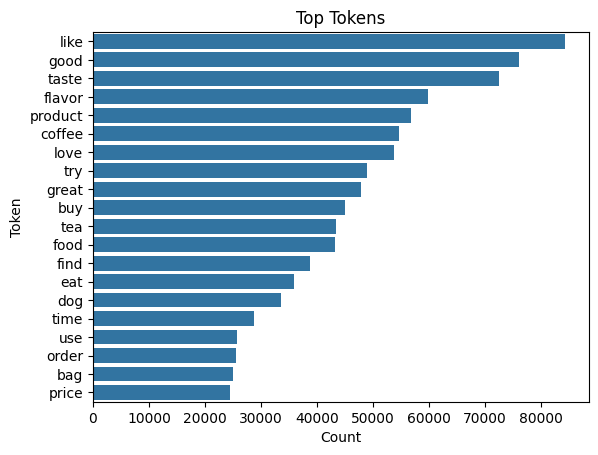

In [18]:
plot_top_tokens(df, column='tokens', top_n=20)